# Multi-Model Text Classification Pipeline

Training 12 models using GloVe and TF-IDF representations with SVM and Linear Regression across 3 CSV files.

**Models to train:**
- 3 CSV files × 2 text representations × 2 classifiers = 12 base models

In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, mean_squared_error, r2_score, roc_auc_score, ConfusionMatrixDisplay
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 1. Load CSV Files

In [41]:
# Load all three CSV files
csv_files = {
    'stopword_hastag_number_mention': 'stopword_hastag_number_mention_labeled2.csv',
    'stopword_lemma_punc_number': 'stopword_lemma_punc_number_labeled2.csv',
    'stopword_spell_lemma_lower': 'stopword_spell_lemma_lower_labeled2.csv'
}

datasets = {}
for name, filename in csv_files.items():
    df = pd.read_csv(filename)
    datasets[name] = df
    print(f"\n{name}:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  Target distribution:\n{df['ground_truth'].value_counts()}")
    print(f"  Missing values: {df.isnull().sum().sum()}")

print("\n✓ All datasets loaded successfully")


stopword_hastag_number_mention:
  Shape: (99, 10)
  Columns: ['movie_title', 'genres', 'content', 'rating', 'movie_id', 'review_id', 'author', 'created_at', 'cleaned_text', 'ground_truth']
  Target distribution:
ground_truth
positive    63
negative    20
neutral     16
Name: count, dtype: int64
  Missing values: 12

stopword_lemma_punc_number:
  Shape: (99, 10)
  Columns: ['movie_title', 'genres', 'content', 'rating', 'movie_id', 'review_id', 'author', 'created_at', 'cleaned_text', 'ground_truth']
  Target distribution:
ground_truth
positive    63
negative    20
neutral     16
Name: count, dtype: int64
  Missing values: 12

stopword_spell_lemma_lower:
  Shape: (99, 10)
  Columns: ['movie_title', 'genres', 'content', 'rating', 'movie_id', 'review_id', 'author', 'created_at', 'cleaned_text', 'ground_truth']
  Target distribution:
ground_truth
positive    63
negative    20
neutral     16
Name: count, dtype: int64
  Missing values: 12

✓ All datasets loaded successfully


## 2. Prepare Data for Modeling

In [42]:
# Prepare data for each dataset
data_splits = {}

for name, df in datasets.items():
    X = df['cleaned_text'].values
    y = df['ground_truth'].values
    
    # Encode labels (assuming binary classification: positive/negative)
    label_mapping = {label: idx for idx, label in enumerate(np.unique(y))}
    y_encoded = np.array([label_mapping[label] for label in y])
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    
    data_splits[name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'label_mapping': label_mapping,
        'reverse_mapping': {v: k for k, v in label_mapping.items()}
    }
    
    print(f"{name}:")
    print(f"  Training set: {len(X_train)} samples")
    print(f"  Test set: {len(X_test)} samples")
    print(f"  Label mapping: {label_mapping}\n")

print("✓ Data prepared and split into train/test sets")

stopword_hastag_number_mention:
  Training set: 79 samples
  Test set: 20 samples
  Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

stopword_lemma_punc_number:
  Training set: 79 samples
  Test set: 20 samples
  Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

stopword_spell_lemma_lower:
  Training set: 79 samples
  Test set: 20 samples
  Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

✓ Data prepared and split into train/test sets


## 3. Text Representation: GloVe Embeddings

In [44]:
def load_glove_embeddings(glove_file):
    """Load GloVe embeddings from file"""
    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
    return embeddings_index

def create_glove_embeddings(texts, embeddings_index, embedding_dim=100):
    """Create GloVe embeddings from texts"""
    embeddings = []
    for text in texts:
        words = text.split()
        valid_vectors = [embeddings_index[word] for word in words if word in embeddings_index]
        
        if valid_vectors:
            doc_vector = np.mean(valid_vectors, axis=0)
        else:
            doc_vector = np.zeros(embedding_dim)
        embeddings.append(doc_vector)
    
    return np.array(embeddings)

# Load GloVe embeddings
print("Loading GloVe embeddings from glove.6B.100d...")
glove_embeddings = load_glove_embeddings(r'C:\Users\Aliel\Desktop\Task_2\final_data\glove.6B.100d.txt')
print(f"✓ Loaded {len(glove_embeddings)} word vectors")

# Create GloVe embeddings for each dataset
glove_representations = {}

for name, splits in data_splits.items():
    print(f"\nCreating GloVe embeddings for {name}...")
    
    # Create embeddings for training and test data
    train_embeddings = create_glove_embeddings(splits['X_train'], glove_embeddings, embedding_dim=100)
    test_embeddings = create_glove_embeddings(splits['X_test'], glove_embeddings, embedding_dim=100)
    
    glove_representations[name] = {
        'X_train': train_embeddings,
        'X_test': test_embeddings,
        'embeddings_index': glove_embeddings
    }
    
    print(f"  Train shape: {train_embeddings.shape}")
    print(f"  Test shape: {test_embeddings.shape}")

print("\n✓ GloVe embeddings created for all datasets")

Loading GloVe embeddings from glove.6B.100d...


✓ Loaded 400000 word vectors

Creating GloVe embeddings for stopword_hastag_number_mention...
  Train shape: (79, 100)
  Test shape: (20, 100)

Creating GloVe embeddings for stopword_lemma_punc_number...
  Train shape: (79, 100)
  Test shape: (20, 100)

Creating GloVe embeddings for stopword_spell_lemma_lower...
  Train shape: (79, 100)
  Test shape: (20, 100)

✓ GloVe embeddings created for all datasets


## 4. Text Representation: TF-IDF

In [45]:
from sklearn.preprocessing import StandardScaler

# Create TF-IDF vectorizer for each dataset
tfidf_representations = {}

for name, splits in data_splits.items():
    print(f"Creating TF-IDF for {name}...")
    
    # Create and fit TF-IDF vectorizer
    vectorizer = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.8)
    X_train_tfidf = vectorizer.fit_transform(splits['X_train'])
    X_test_tfidf = vectorizer.transform(splits['X_test'])
    
    # Scale sparse TF-IDF features (with_mean=False to preserve sparsity)
    scaler = StandardScaler(with_mean=False)
    X_train_tfidf_scaled = scaler.fit_transform(X_train_tfidf)
    X_test_tfidf_scaled = scaler.transform(X_test_tfidf)
    
    tfidf_representations[name] = {
        'X_train': X_train_tfidf_scaled,
        'X_test': X_test_tfidf_scaled,
        'vectorizer': vectorizer,
        'scaler': scaler
    }
    
    print(f"  Train shape: {X_train_tfidf_scaled.shape}")
    print(f"  Test shape: {X_test_tfidf_scaled.shape}")
    print(f"  Vocabulary size: {len(vectorizer.get_feature_names_out())}\n")

print("✓ TF-IDF vectorization completed for all datasets (scaled with sparse awareness)")

Creating TF-IDF for stopword_hastag_number_mention...
  Train shape: (79, 1000)
  Test shape: (20, 1000)
  Vocabulary size: 1000

Creating TF-IDF for stopword_lemma_punc_number...
  Train shape: (79, 1000)
  Test shape: (20, 1000)
  Vocabulary size: 1000

Creating TF-IDF for stopword_spell_lemma_lower...
  Train shape: (79, 1000)
  Test shape: (20, 1000)
  Vocabulary size: 1000

✓ TF-IDF vectorization completed for all datasets (scaled with sparse awareness)


## 5. Train SVM Models

In [46]:
from sklearn.preprocessing import label_binarize

# Dictionary to store all models and results
svm_models = {}
svm_results = []
svm_confusion_matrices = {}
svm_roc_auc = {}

for dataset_name in data_splits.keys():
    y_train = data_splits[dataset_name]['y_train']
    y_test = data_splits[dataset_name]['y_test']
    num_classes = len(np.unique(y_test))
    
    # ============ SVM with GloVe ============
    print(f"\nTraining SVM + GloVe for {dataset_name}...")
    X_train_glove = glove_representations[dataset_name]['X_train']
    X_test_glove = glove_representations[dataset_name]['X_test']
    
    svm_glove = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42, probability=True)
    svm_glove.fit(X_train_glove, y_train)
    y_pred_glove = svm_glove.predict(X_test_glove)
    y_proba_glove = svm_glove.predict_proba(X_test_glove)
    
    acc_glove = accuracy_score(y_test, y_pred_glove)
    prec_glove = precision_score(y_test, y_pred_glove, average='weighted', zero_division=0)
    rec_glove = recall_score(y_test, y_pred_glove, average='weighted', zero_division=0)
    f1_glove = f1_score(y_test, y_pred_glove, average='weighted', zero_division=0)
    
    # Confusion Matrix
    cm_glove = confusion_matrix(y_test, y_pred_glove)
    svm_confusion_matrices[f'{dataset_name}_glove_svm'] = cm_glove
    
    # ROC-AUC (One-vs-Rest for multiclass)
    if num_classes == 2:
        roc_auc_glove = roc_auc_score(y_test, y_proba_glove[:, 1])
    else:
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        roc_auc_glove = roc_auc_score(y_test_bin, y_proba_glove, average='weighted', multi_class='ovr')
    svm_roc_auc[f'{dataset_name}_glove_svm'] = roc_auc_glove
    
    svm_models[f'{dataset_name}_glove_svm'] = {
        'model': svm_glove,
        'type': 'SVM',
        'representation': 'GloVe'
    }
    
    svm_results.append({
        'Dataset': dataset_name,
        'Model': 'SVM + GloVe',
        'Accuracy': acc_glove,
        'Precision': prec_glove,
        'Recall': rec_glove,
        'F1-Score': f1_glove,
        'ROC-AUC': roc_auc_glove
    })
    
    print(f"  Accuracy: {acc_glove:.4f}, F1: {f1_glove:.4f}, ROC-AUC: {roc_auc_glove:.4f}")
    
    # ============ SVM with TF-IDF ============
    print(f"Training SVM + TF-IDF for {dataset_name}...")
    X_train_tfidf = tfidf_representations[dataset_name]['X_train']
    X_test_tfidf = tfidf_representations[dataset_name]['X_test']
    
    # Use linear kernel for sparse TF-IDF (more suitable), high C to force fitting
    svm_tfidf = SVC(kernel='linear', C=100.0, class_weight='balanced', random_state=42, max_iter=5000, probability=True)
    svm_tfidf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = svm_tfidf.predict(X_test_tfidf)
    y_proba_tfidf = svm_tfidf.predict_proba(X_test_tfidf)
    
    acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
    prec_tfidf = precision_score(y_test, y_pred_tfidf, average='weighted', zero_division=0)
    rec_tfidf = recall_score(y_test, y_pred_tfidf, average='weighted', zero_division=0)
    f1_tfidf = f1_score(y_test, y_pred_tfidf, average='weighted', zero_division=0)
    
    # Confusion Matrix
    cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
    svm_confusion_matrices[f'{dataset_name}_tfidf_svm'] = cm_tfidf
    
    # ROC-AUC (One-vs-Rest for multiclass)
    if num_classes == 2:
        roc_auc_tfidf = roc_auc_score(y_test, y_proba_tfidf[:, 1])
    else:
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        roc_auc_tfidf = roc_auc_score(y_test_bin, y_proba_tfidf, average='weighted', multi_class='ovr')
    svm_roc_auc[f'{dataset_name}_tfidf_svm'] = roc_auc_tfidf
    
    svm_models[f'{dataset_name}_tfidf_svm'] = {
        'model': svm_tfidf,
        'type': 'SVM',
        'representation': 'TF-IDF'
    }
    
    svm_results.append({
        'Dataset': dataset_name,
        'Model': 'SVM + TF-IDF',
        'Accuracy': acc_tfidf,
        'Precision': prec_tfidf,
        'Recall': rec_tfidf,
        'F1-Score': f1_tfidf,
        'ROC-AUC': roc_auc_tfidf
    })
    
    print(f"  Accuracy: {acc_tfidf:.4f}, F1: {f1_tfidf:.4f}, ROC-AUC: {roc_auc_tfidf:.4f}")

print("\n✓ SVM training completed (6 models trained)")


Training SVM + GloVe for stopword_hastag_number_mention...


  Accuracy: 0.7000, F1: 0.6967, ROC-AUC: 0.7101
Training SVM + TF-IDF for stopword_hastag_number_mention...
  Accuracy: 0.6500, F1: 0.5281, ROC-AUC: 0.9341

Training SVM + GloVe for stopword_lemma_punc_number...
  Accuracy: 0.6500, F1: 0.6916, ROC-AUC: 0.6702
Training SVM + TF-IDF for stopword_lemma_punc_number...
  Accuracy: 0.6500, F1: 0.5121, ROC-AUC: 0.8292

Training SVM + GloVe for stopword_spell_lemma_lower...
  Accuracy: 0.5500, F1: 0.5997, ROC-AUC: 0.5139
Training SVM + TF-IDF for stopword_spell_lemma_lower...
  Accuracy: 0.6500, F1: 0.5281, ROC-AUC: 0.8048

✓ SVM training completed (6 models trained)


In [47]:
    # ============ SVM + TF-IDF ============
    X_test_tfidf = tfidf_representations[dataset_name]['X_test']
    svm_tfidf_debug = SVC(kernel='linear', C=100.0, class_weight='balanced', random_state=42, max_iter=5000)
    svm_tfidf_debug.fit(tfidf_representations[dataset_name]['X_train'], data_splits[dataset_name]['y_train'])
    y_pred_tfidf = svm_tfidf_debug.predict(X_test_tfidf)
    
    reverse_mapping = data_splits[dataset_name]['reverse_mapping']  # Get reverse_mapping from data_splits
    unique_preds_tfidf = np.unique(y_pred_tfidf)
    print(f"  SVM + TF-IDF (kernel='linear', C=100.0, scaled):")
    print(f"    Unique predictions: {[reverse_mapping[p] for p in unique_preds_tfidf]}")
    print(f"    Prediction counts: {np.bincount(y_pred_tfidf)}")

  SVM + TF-IDF (kernel='linear', C=100.0, scaled):
    Unique predictions: ['neutral', 'positive']
    Prediction counts: [ 0  1 19]


## 6. Train Linear Regression Models

In [48]:
# Using Linear Regression for regression task on encoded labels
from sklearn.preprocessing import label_binarize

lr_models = {}
lr_results = []
lr_confusion_matrices = {}
lr_roc_auc = {}

for dataset_name in data_splits.keys():
    y_train = data_splits[dataset_name]['y_train']
    y_test = data_splits[dataset_name]['y_test']
    num_classes = len(np.unique(y_test))
    
    # ============ Linear Regression with GloVe ============
    print(f"\nTraining Linear Regression + GloVe for {dataset_name}...")
    X_train_glove = glove_representations[dataset_name]['X_train']
    X_test_glove = glove_representations[dataset_name]['X_test']
    
    lr_glove = LinearRegression()
    lr_glove.fit(X_train_glove, y_train)
    y_pred_glove = lr_glove.predict(X_test_glove)
    # Round predictions to nearest class
    y_pred_glove_rounded = np.round(y_pred_glove).astype(int)
    y_pred_glove_rounded = np.clip(y_pred_glove_rounded, 0, num_classes - 1)
    
    acc_glove = accuracy_score(y_test, y_pred_glove_rounded)
    prec_glove = precision_score(y_test, y_pred_glove_rounded, average='weighted', zero_division=0)
    rec_glove = recall_score(y_test, y_pred_glove_rounded, average='weighted', zero_division=0)
    f1_glove = f1_score(y_test, y_pred_glove_rounded, average='weighted', zero_division=0)
    mse_glove = mean_squared_error(y_test, y_pred_glove)
    r2_glove = r2_score(y_test, y_pred_glove)
    
    # Confusion Matrix
    cm_glove = confusion_matrix(y_test, y_pred_glove_rounded)
    lr_confusion_matrices[f'{dataset_name}_glove_lr'] = cm_glove
    
    # ROC-AUC (One-vs-Rest for multiclass using raw predictions)
    if num_classes == 2:
        y_pred_glove_prob = (y_pred_glove - y_pred_glove.min()) / (y_pred_glove.max() - y_pred_glove.min())
        roc_auc_glove = roc_auc_score(y_test, y_pred_glove_prob)
    else:
        # Normalize to [0,1] for each class
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        y_pred_glove_norm = np.column_stack([
            np.exp(y_pred_glove - k) / (1 + np.sum(np.exp(y_pred_glove - np.arange(num_classes)[:, np.newaxis]), axis=0))
            for k in range(num_classes)
        ])
        roc_auc_glove = roc_auc_score(y_test_bin, y_pred_glove_norm, average='weighted', multi_class='ovr')
    lr_roc_auc[f'{dataset_name}_glove_lr'] = roc_auc_glove
    
    lr_models[f'{dataset_name}_glove_lr'] = {
        'model': lr_glove,
        'type': 'Linear Regression',
        'representation': 'GloVe'
    }
    
    lr_results.append({
        'Dataset': dataset_name,
        'Model': 'Linear Regression + GloVe',
        'Accuracy': acc_glove,
        'Precision': prec_glove,
        'Recall': rec_glove,
        'F1-Score': f1_glove,
        'MSE': mse_glove,
        'R2': r2_glove,
        'ROC-AUC': roc_auc_glove
    })
    
    print(f"  Accuracy: {acc_glove:.4f}, F1: {f1_glove:.4f}, MSE: {mse_glove:.4f}, R²: {r2_glove:.4f}, ROC-AUC: {roc_auc_glove:.4f}")
    
    # ============ Linear Regression with TF-IDF ============
    print(f"Training Linear Regression + TF-IDF for {dataset_name}...")
    X_train_tfidf = tfidf_representations[dataset_name]['X_train']
    X_test_tfidf = tfidf_representations[dataset_name]['X_test']
    
    lr_tfidf = LinearRegression()
    lr_tfidf.fit(X_train_tfidf, y_train)
    y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)
    # Round predictions to nearest class
    y_pred_tfidf_rounded = np.round(y_pred_tfidf).astype(int)
    y_pred_tfidf_rounded = np.clip(y_pred_tfidf_rounded, 0, num_classes - 1)
    
    acc_tfidf = accuracy_score(y_test, y_pred_tfidf_rounded)
    prec_tfidf = precision_score(y_test, y_pred_tfidf_rounded, average='weighted', zero_division=0)
    rec_tfidf = recall_score(y_test, y_pred_tfidf_rounded, average='weighted', zero_division=0)
    f1_tfidf = f1_score(y_test, y_pred_tfidf_rounded, average='weighted', zero_division=0)
    mse_tfidf = mean_squared_error(y_test, y_pred_tfidf)
    r2_tfidf = r2_score(y_test, y_pred_tfidf)
    
    # Confusion Matrix
    cm_tfidf = confusion_matrix(y_test, y_pred_tfidf_rounded)
    lr_confusion_matrices[f'{dataset_name}_tfidf_lr'] = cm_tfidf
    
    # ROC-AUC (One-vs-Rest for multiclass using raw predictions)
    if num_classes == 2:
        y_pred_tfidf_prob = (y_pred_tfidf - y_pred_tfidf.min()) / (y_pred_tfidf.max() - y_pred_tfidf.min())
        roc_auc_tfidf = roc_auc_score(y_test, y_pred_tfidf_prob)
    else:
        y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
        y_pred_tfidf_norm = np.column_stack([
            np.exp(y_pred_tfidf - k) / (1 + np.sum(np.exp(y_pred_tfidf - np.arange(num_classes)[:, np.newaxis]), axis=0))
            for k in range(num_classes)
        ])
        roc_auc_tfidf = roc_auc_score(y_test_bin, y_pred_tfidf_norm, average='weighted', multi_class='ovr')
    lr_roc_auc[f'{dataset_name}_tfidf_lr'] = roc_auc_tfidf
    
    lr_models[f'{dataset_name}_tfidf_lr'] = {
        'model': lr_tfidf,
        'type': 'Linear Regression',
        'representation': 'TF-IDF'
    }
    
    lr_results.append({
        'Dataset': dataset_name,
        'Model': 'Linear Regression + TF-IDF',
        'Accuracy': acc_tfidf,
        'Precision': prec_tfidf,
        'Recall': rec_tfidf,
        'F1-Score': f1_tfidf,
        'MSE': mse_tfidf,
        'R2': r2_tfidf,
        'ROC-AUC': roc_auc_tfidf
    })
    
    print(f"  Accuracy: {acc_tfidf:.4f}, F1: {f1_tfidf:.4f}, MSE: {mse_tfidf:.4f}, R²: {r2_tfidf:.4f}, ROC-AUC: {roc_auc_tfidf:.4f}")

print("\n✓ Linear Regression training completed (6 models trained)")


Training Linear Regression + GloVe for stopword_hastag_number_mention...
  Accuracy: 0.5500, F1: 0.5476, MSE: 4.3205, R²: -5.6726, ROC-AUC: 0.6276
Training Linear Regression + TF-IDF for stopword_hastag_number_mention...


  Accuracy: 0.6500, F1: 0.6344, MSE: 0.4444, R²: 0.3136, ROC-AUC: 0.6785

Training Linear Regression + GloVe for stopword_lemma_punc_number...
  Accuracy: 0.6500, F1: 0.6476, MSE: 5.2328, R²: -7.0815, ROC-AUC: 0.6013
Training Linear Regression + TF-IDF for stopword_lemma_punc_number...
  Accuracy: 0.5500, F1: 0.5375, MSE: 0.4864, R²: 0.2488, ROC-AUC: 0.6331

Training Linear Regression + GloVe for stopword_spell_lemma_lower...
  Accuracy: 0.3500, F1: 0.3595, MSE: 4.8003, R²: -6.4136, ROC-AUC: 0.5973
Training Linear Regression + TF-IDF for stopword_spell_lemma_lower...
  Accuracy: 0.5500, F1: 0.5375, MSE: 0.5027, R²: 0.2237, ROC-AUC: 0.6203

✓ Linear Regression training completed (6 models trained)


## 7. Model Evaluation and Comparison

CONFUSION MATRICES - SVM Models


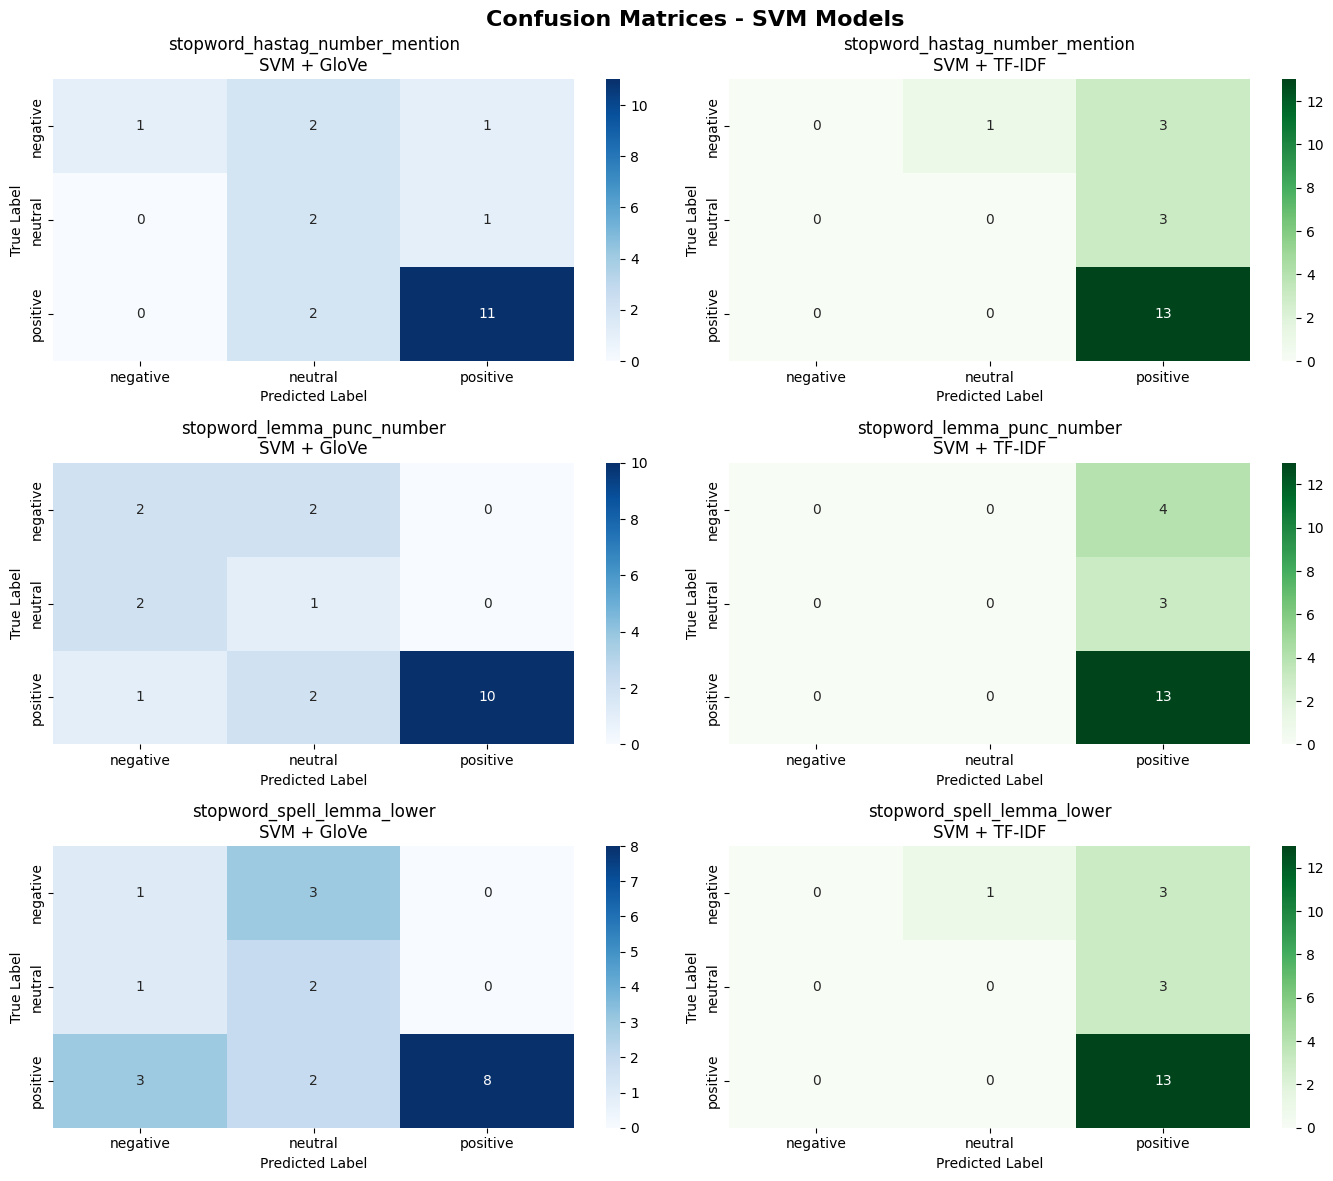


CONFUSION MATRICES - Linear Regression Models


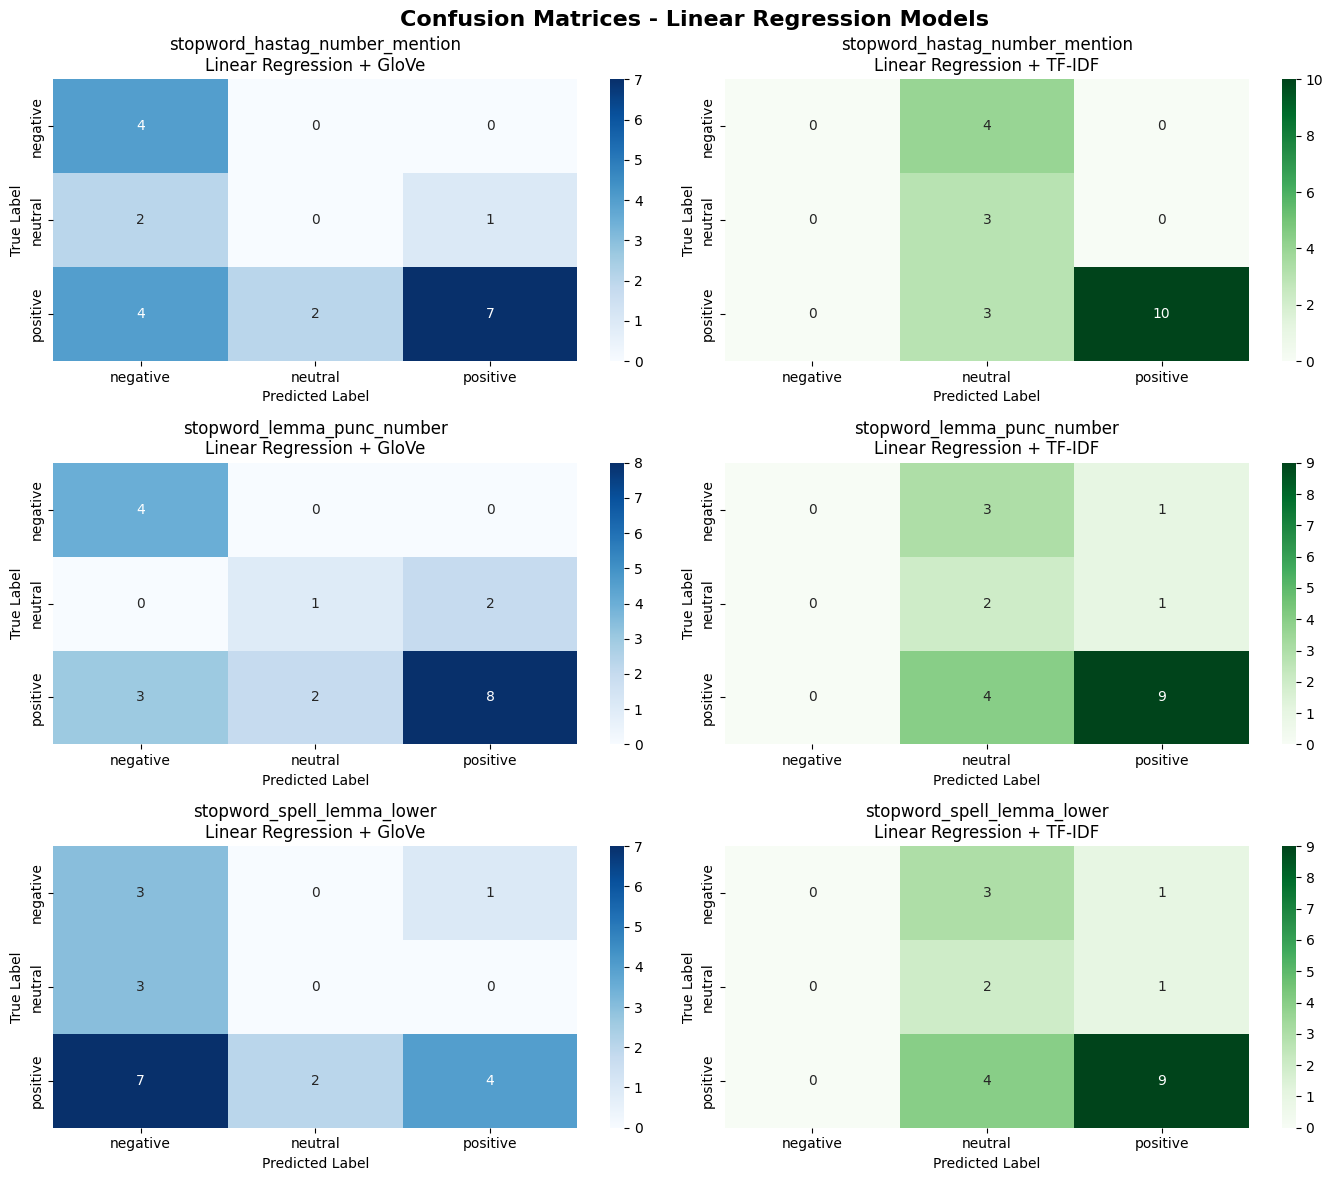


✓ Confusion matrices visualized for all models


In [49]:
# Visualize Confusion Matrices for SVM Models
print("="*80)
print("CONFUSION MATRICES - SVM Models")
print("="*80)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices - SVM Models', fontsize=16, fontweight='bold')

dataset_list = list(data_splits.keys())
for idx, dataset_name in enumerate(dataset_list):
    reverse_mapping = data_splits[dataset_name]['reverse_mapping']
    labels = [reverse_mapping[i] for i in sorted(reverse_mapping.keys())]
    
    # GloVe
    cm_glove = svm_confusion_matrices[f'{dataset_name}_glove_svm']
    sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0], 
                xticklabels=labels, yticklabels=labels, cbar=True)
    axes[idx, 0].set_title(f'{dataset_name}\nSVM + GloVe')
    axes[idx, 0].set_ylabel('True Label')
    axes[idx, 0].set_xlabel('Predicted Label')
    
    # TF-IDF
    cm_tfidf = svm_confusion_matrices[f'{dataset_name}_tfidf_svm']
    sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens', ax=axes[idx, 1],
                xticklabels=labels, yticklabels=labels, cbar=True)
    axes[idx, 1].set_title(f'{dataset_name}\nSVM + TF-IDF')
    axes[idx, 1].set_ylabel('True Label')
    axes[idx, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Visualize Confusion Matrices for Linear Regression Models
print("\n" + "="*80)
print("CONFUSION MATRICES - Linear Regression Models")
print("="*80)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices - Linear Regression Models', fontsize=16, fontweight='bold')

for idx, dataset_name in enumerate(dataset_list):
    reverse_mapping = data_splits[dataset_name]['reverse_mapping']
    labels = [reverse_mapping[i] for i in sorted(reverse_mapping.keys())]
    
    # GloVe
    cm_glove = lr_confusion_matrices[f'{dataset_name}_glove_lr']
    sns.heatmap(cm_glove, annot=True, fmt='d', cmap='Blues', ax=axes[idx, 0],
                xticklabels=labels, yticklabels=labels, cbar=True)
    axes[idx, 0].set_title(f'{dataset_name}\nLinear Regression + GloVe')
    axes[idx, 0].set_ylabel('True Label')
    axes[idx, 0].set_xlabel('Predicted Label')
    
    # TF-IDF
    cm_tfidf = lr_confusion_matrices[f'{dataset_name}_tfidf_lr']
    sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens', ax=axes[idx, 1],
                xticklabels=labels, yticklabels=labels, cbar=True)
    axes[idx, 1].set_title(f'{dataset_name}\nLinear Regression + TF-IDF')
    axes[idx, 1].set_ylabel('True Label')
    axes[idx, 1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("\n✓ Confusion matrices visualized for all models")


COMPLETE MODEL PERFORMANCE SUMMARY - ALL 12 MODELS
                       Dataset                      Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC      MSE        R2
stopword_hastag_number_mention                SVM + GloVe      0.70   0.800000    0.70  0.696667 0.710058      NaN       NaN
stopword_hastag_number_mention               SVM + TF-IDF      0.65   0.444737    0.65  0.528125 0.934060      NaN       NaN
    stopword_lemma_punc_number                SVM + GloVe      0.65   0.760000    0.65  0.691606 0.670168      NaN       NaN
    stopword_lemma_punc_number               SVM + TF-IDF      0.65   0.422500    0.65  0.512121 0.829175      NaN       NaN
    stopword_spell_lemma_lower                SVM + GloVe      0.55   0.732857    0.55  0.599683 0.513892      NaN       NaN
    stopword_spell_lemma_lower               SVM + TF-IDF      0.65   0.444737    0.65  0.528125 0.804753      NaN       NaN
stopword_hastag_number_mention  Linear Regression + GloVe      0.55   0.6

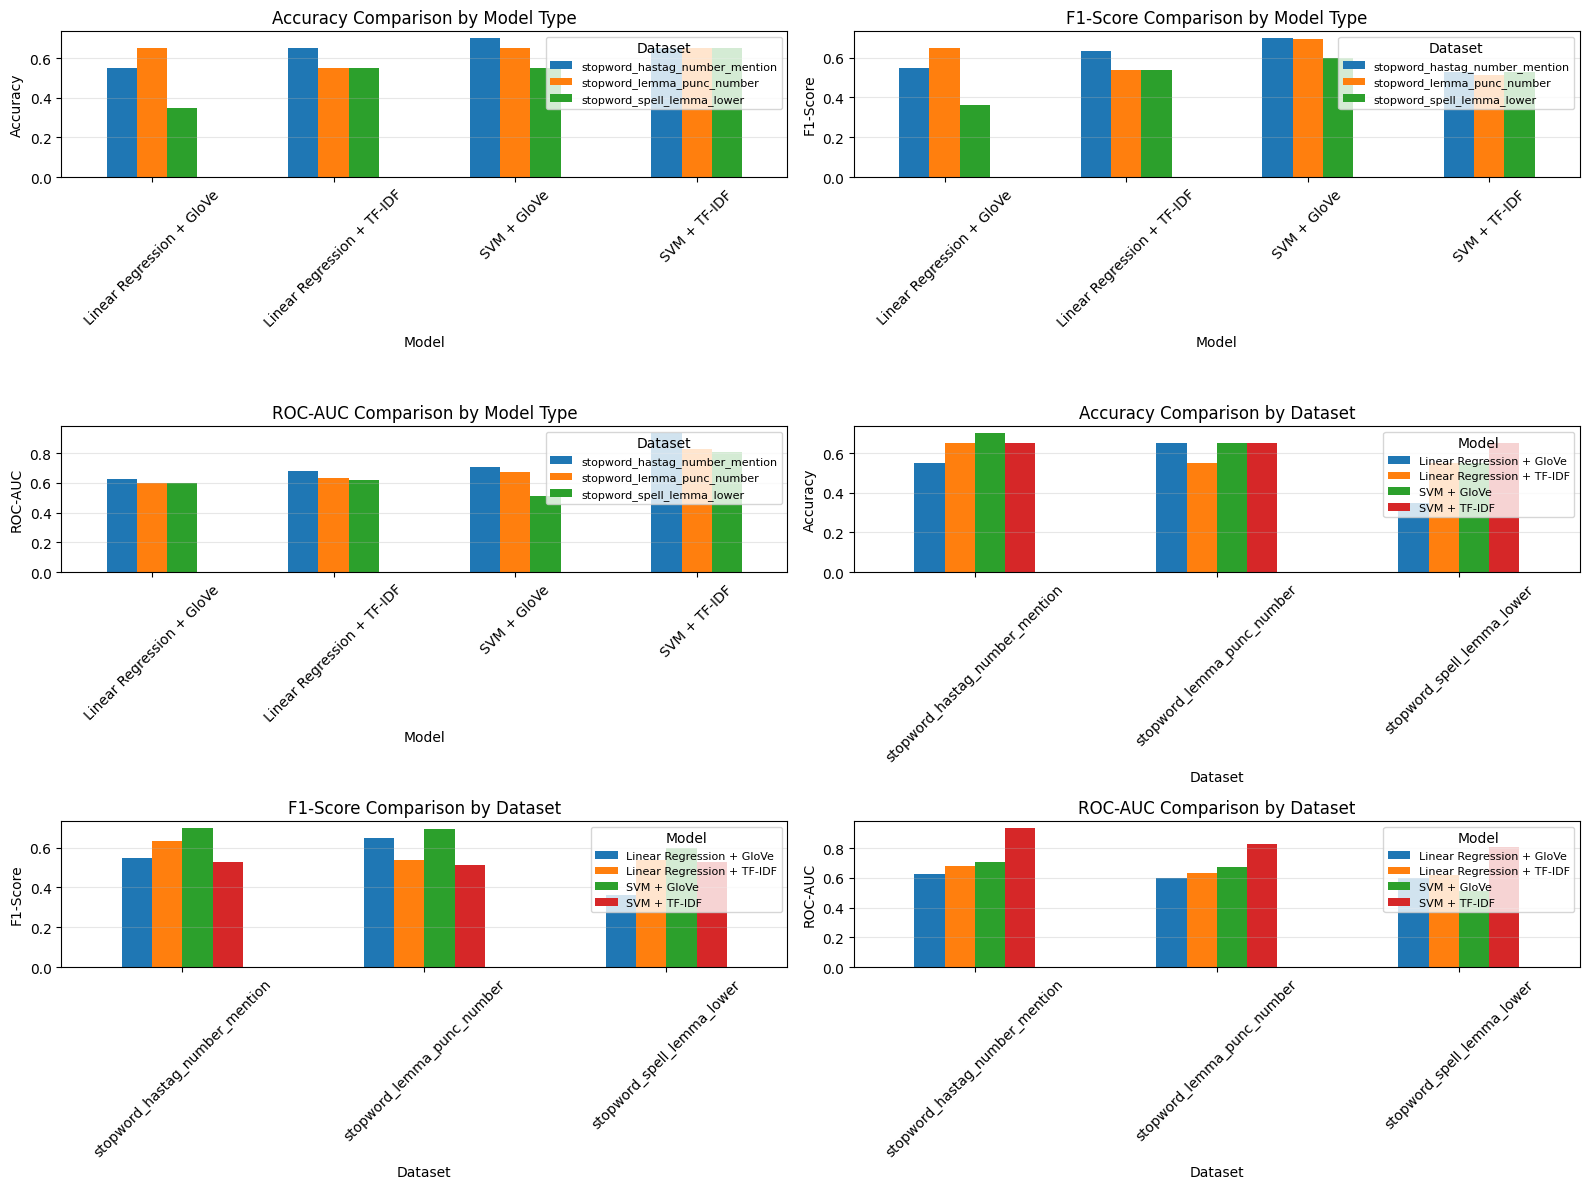


✓ All models evaluated and visualized with comprehensive metrics


In [50]:
# Combine all results
all_results = svm_results + lr_results
results_df = pd.DataFrame(all_results)

print("\n" + "="*80)
print("COMPLETE MODEL PERFORMANCE SUMMARY - ALL 12 MODELS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Summary statistics (use only classification metrics for comparison)
classification_cols = ['Accuracy', 'F1-Score', 'ROC-AUC']
print("\nSummary by Model Type (Classification Metrics):")
model_summary = results_df.groupby('Model')[classification_cols].mean()
print(model_summary.round(4))

print("\nSummary by Dataset (Classification Metrics):")
dataset_summary = results_df.groupby('Dataset')[classification_cols].mean()
print(dataset_summary.round(4))

# Linear Regression specific metrics
print("\nLinear Regression - Regression Metrics (MSE & R²):")
lr_metrics = results_df[results_df['Model'].str.contains('Linear Regression')][['Dataset', 'Model', 'MSE', 'R2', 'ROC-AUC']]
print(lr_metrics.to_string(index=False))

# ROC-AUC Summary
print("\n" + "="*80)
print("ROC-AUC SCORES BY MODEL")
print("="*80)
roc_auc_summary = results_df[['Model', 'Dataset', 'ROC-AUC']].sort_values('ROC-AUC', ascending=False)
print(roc_auc_summary.to_string(index=False))

# Find best models
print("\n" + "="*80)
print("BEST MODELS")
print("="*80)
best_accuracy_idx = results_df['Accuracy'].idxmax()
best_f1_idx = results_df['F1-Score'].idxmax()
best_roc_auc_idx = results_df['ROC-AUC'].idxmax()

print(f"\nBest by Accuracy:")
print(results_df.iloc[best_accuracy_idx])

print(f"\nBest by F1-Score:")
print(results_df.iloc[best_f1_idx])

print(f"\nBest by ROC-AUC:")
print(results_df.iloc[best_roc_auc_idx])

# Create comparison visualizations (6 plots now)
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Plot 1: Accuracy by Model
ax1 = axes[0, 0]
results_pivot = results_df.pivot(index='Model', columns='Dataset', values='Accuracy')
results_pivot.plot(kind='bar', ax=ax1)
ax1.set_title('Accuracy Comparison by Model Type')
ax1.set_ylabel('Accuracy')
ax1.legend(title='Dataset', fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: F1-Score by Model
ax2 = axes[0, 1]
results_pivot_f1 = results_df.pivot(index='Model', columns='Dataset', values='F1-Score')
results_pivot_f1.plot(kind='bar', ax=ax2)
ax2.set_title('F1-Score Comparison by Model Type')
ax2.set_ylabel('F1-Score')
ax2.legend(title='Dataset', fontsize=8)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Plot 3: ROC-AUC by Model
ax3 = axes[1, 0]
results_pivot_roc = results_df.pivot(index='Model', columns='Dataset', values='ROC-AUC')
results_pivot_roc.plot(kind='bar', ax=ax3)
ax3.set_title('ROC-AUC Comparison by Model Type')
ax3.set_ylabel('ROC-AUC')
ax3.legend(title='Dataset', fontsize=8)
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# Plot 4: Accuracy by Dataset
ax4 = axes[1, 1]
dataset_pivot = results_df.pivot(index='Dataset', columns='Model', values='Accuracy')
dataset_pivot.plot(kind='bar', ax=ax4)
ax4.set_title('Accuracy Comparison by Dataset')
ax4.set_ylabel('Accuracy')
ax4.legend(title='Model', fontsize=8)
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# Plot 5: F1-Score by Dataset
ax5 = axes[2, 0]
dataset_pivot_f1 = results_df.pivot(index='Dataset', columns='Model', values='F1-Score')
dataset_pivot_f1.plot(kind='bar', ax=ax5)
ax5.set_title('F1-Score Comparison by Dataset')
ax5.set_ylabel('F1-Score')
ax5.legend(title='Model', fontsize=8)
ax5.grid(axis='y', alpha=0.3)
ax5.tick_params(axis='x', rotation=45)

# Plot 6: ROC-AUC by Dataset
ax6 = axes[2, 1]
dataset_pivot_roc = results_df.pivot(index='Dataset', columns='Model', values='ROC-AUC')
dataset_pivot_roc.plot(kind='bar', ax=ax6)
ax6.set_title('ROC-AUC Comparison by Dataset')
ax6.set_ylabel('ROC-AUC')
ax6.legend(title='Model', fontsize=8)
ax6.grid(axis='y', alpha=0.3)
ax6.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n✓ All models evaluated and visualized with comprehensive metrics")

## 8. Model Storage & Summary

In [51]:
import pickle
import json
from datetime import datetime

# Save results to CSV
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_df.to_csv(f'model_results_{timestamp}.csv', index=False)
print(f"Results saved to: model_results_{timestamp}.csv")

# Create comprehensive summary
summary = {
    'total_models': len(svm_models) + len(lr_models),
    'datasets_used': list(data_splits.keys()),
    'text_representations': ['GloVe (300d)', 'TF-IDF'],
    'classifiers': ['SVM', 'Linear Regression'],
    'timestamp': timestamp,
    'glove_file': 'glove.6B.300d',
    'best_model_by_accuracy': {
        'model_name': results_df.iloc[best_accuracy_idx]['Model'],
        'dataset': results_df.iloc[best_accuracy_idx]['Dataset'],
        'accuracy': float(results_df.iloc[best_accuracy_idx]['Accuracy'])
    },
    'best_model_by_f1': {
        'model_name': results_df.iloc[best_f1_idx]['Model'],
        'dataset': results_df.iloc[best_f1_idx]['Dataset'],
        'f1_score': float(results_df.iloc[best_f1_idx]['F1-Score'])
    },
    'model_details': results_df.to_dict('records')
}

# Save summary to JSON
with open(f'model_summary_{timestamp}.json', 'w') as f:
    json.dump(summary, f, indent=4)
print(f"Summary saved to: model_summary_{timestamp}.json")

# Print final summary
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"✓ Total Models Trained: {summary['total_models']}")
print(f"✓ Datasets Used: {', '.join(summary['datasets_used'])}")
print(f"✓ Text Representations: {', '.join(summary['text_representations'])}")
print(f"✓ Classifiers: {', '.join(summary['classifiers'])}")
print(f"✓ GloVe File: {summary['glove_file']}")
print(f"\n✓ Best Model (Accuracy): {summary['best_model_by_accuracy']['model_name']}")
print(f"   Dataset: {summary['best_model_by_accuracy']['dataset']}")
print(f"   Accuracy: {summary['best_model_by_accuracy']['accuracy']:.4f}")
print(f"\n✓ Best Model (F1-Score): {summary['best_model_by_f1']['model_name']}")
print(f"   Dataset: {summary['best_model_by_f1']['dataset']}")
print(f"   F1-Score: {summary['best_model_by_f1']['f1_score']:.4f}")
print("="*80)

print("\nTrained Models Dictionary:")
print(f"  SVM Models: {list(svm_models.keys())}")
print(f"  Linear Regression Models: {list(lr_models.keys())}")

print("\n✓ All models trained, evaluated, and documented!")

Results saved to: model_results_20260418_040049.csv
Summary saved to: model_summary_20260418_040049.json

TRAINING SUMMARY
✓ Total Models Trained: 12
✓ Datasets Used: stopword_hastag_number_mention, stopword_lemma_punc_number, stopword_spell_lemma_lower
✓ Text Representations: GloVe (300d), TF-IDF
✓ Classifiers: SVM, Linear Regression
✓ GloVe File: glove.6B.300d

✓ Best Model (Accuracy): SVM + GloVe
   Dataset: stopword_hastag_number_mention
   Accuracy: 0.7000

✓ Best Model (F1-Score): SVM + GloVe
   Dataset: stopword_hastag_number_mention
   F1-Score: 0.6967

Trained Models Dictionary:
  SVM Models: ['stopword_hastag_number_mention_glove_svm', 'stopword_hastag_number_mention_tfidf_svm', 'stopword_lemma_punc_number_glove_svm', 'stopword_lemma_punc_number_tfidf_svm', 'stopword_spell_lemma_lower_glove_svm', 'stopword_spell_lemma_lower_tfidf_svm']
  Linear Regression Models: ['stopword_hastag_number_mention_glove_lr', 'stopword_hastag_number_mention_tfidf_lr', 'stopword_lemma_punc_number

In [52]:
#ُ OPTIMIZATION
# SELECT BEST DATASET + FEATURES

best_dataset = 'stopword_hastag_number_mention'

X_train_glove = glove_representations[best_dataset]['X_train']
X_test_glove = glove_representations[best_dataset]['X_test']

X_train_tfidf = tfidf_representations[best_dataset]['X_train']
X_test_tfidf = tfidf_representations[best_dataset]['X_test']

y_train = data_splits[best_dataset]['y_train']
y_test = data_splits[best_dataset]['y_test']

In [53]:
#BASELINE (BEFORE OPTIMIZATION)
baseline_f1 = results_df[
    (results_df['Dataset'] == best_dataset) & 
    (results_df['Model'] == 'SVM + GloVe')
]['F1-Score'].values[0]

print("Baseline F1 (SVM + GloVe):", baseline_f1)

Baseline F1 (SVM + GloVe): 0.6966666666666667


In [54]:
#OPTIMIZE SVM (MAIN PART)
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],  # required by assignment
    'gamma': ['scale', 'auto'],
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_train_glove, y_train)

best_svm = grid_svm.best_estimator_

print("Best SVM Params:", grid_svm.best_params_)

Best SVM Params: {'C': 10, 'class_weight': None, 'gamma': 'scale', 'kernel': 'linear'}


In [55]:
#Evaluate optimized SVM
y_pred_svm_opt = best_svm.predict(X_test_glove)

f1_svm_opt = f1_score(y_test, y_pred_svm_opt, average='weighted')
acc_svm_opt = accuracy_score(y_test, y_pred_svm_opt)

print("\nOptimized SVM Results:")
print("F1:", f1_svm_opt)
print("Accuracy:", acc_svm_opt)
print(classification_report(y_test, y_pred_svm_opt))


Optimized SVM Results:
F1: 0.8444545454545456
Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.57      1.00      0.73         4
           1       1.00      0.33      0.50         3
           2       1.00      0.92      0.96        13

    accuracy                           0.85        20
   macro avg       0.86      0.75      0.73        20
weighted avg       0.91      0.85      0.84        20



In [56]:
#REPLACE LINEAR REGRESSION → LOGISTIC REGRESSION
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid_lr,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_train_tfidf, y_train)

best_lr = grid_lr.best_estimator_

print("Best Logistic Regression Params:", grid_lr.best_params_)

Best Logistic Regression Params: {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}


In [57]:
#Evaluate Logistic Regression
y_pred_lr_opt = best_lr.predict(X_test_tfidf)

f1_lr_opt = f1_score(y_test, y_pred_lr_opt, average='weighted')

print("\nOptimized Logistic Regression Results:")
print("F1:", f1_lr_opt)
print(classification_report(y_test, y_pred_lr_opt))


Optimized Logistic Regression Results:
F1: 0.5451612903225806
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.00      0.00      0.00         3
           2       0.72      1.00      0.84        13

    accuracy                           0.65        20
   macro avg       0.24      0.33      0.28        20
weighted avg       0.47      0.65      0.55        20



In [58]:
#BEFORE vs AFTER
comparison_df = pd.DataFrame({
    'Model': ['SVM Before', 'SVM After'],
    'F1 Score': [baseline_f1, f1_svm_opt]
})

print("\nMODEL COMPARISON:")
print(comparison_df)


MODEL COMPARISON:
        Model  F1 Score
0  SVM Before  0.696667
1   SVM After  0.844455


In [59]:
#check 20% improvement
random_f1 = 0.5

improvement = ((f1_svm_opt - random_f1) / random_f1) * 100

print("\nImprovement over random (%):", improvement)


Improvement over random (%): 68.89090909090912


In [60]:
best_row = results_df.iloc[best_accuracy_idx]

best_model_name = best_row['Model']
best_dataset = best_row['Dataset']

print("Best Model:", best_model_name)
print("Best Dataset:", best_dataset)

Best Model: SVM + GloVe
Best Dataset: stopword_hastag_number_mention


In [61]:
print(svm_models.keys())

dict_keys(['stopword_hastag_number_mention_glove_svm', 'stopword_hastag_number_mention_tfidf_svm', 'stopword_lemma_punc_number_glove_svm', 'stopword_lemma_punc_number_tfidf_svm', 'stopword_spell_lemma_lower_glove_svm', 'stopword_spell_lemma_lower_tfidf_svm'])


In [62]:
best_model_name = 'stopword_hastag_number_mention_glove_svm'

best_model = svm_models[best_model_name]

In [63]:
X_test = glove_representations[best_dataset]['X_test']
y_test = data_splits[best_dataset]['y_test']
y_pred = best_model['model'].predict(X_test)

In [64]:
errors_df = pd.DataFrame({
    "text": data_splits[best_dataset]['X_test'],
    "true_label": y_test,
    "pred_label": y_pred
})

wrong_predictions = errors_df[errors_df["true_label"] != errors_df["pred_label"]]

print("Errors:", len(wrong_predictions))

Errors: 6


In [65]:
error_rate = len(wrong_predictions) / len(errors_df)

print("Error Rate:", round(error_rate, 4))
print("Accuracy:", round(1 - error_rate, 4))

Error Rate: 0.3
Accuracy: 0.7


In [66]:
wrong_predictions.groupby(["true_label", "pred_label"]).size().sort_values(ascending=False)

true_label  pred_label
0           1             2
2           1             2
0           2             1
1           2             1
dtype: int64

In [67]:
wrong_predictions.sample(6, random_state=42)

,text,true_label,pred_label
6,Full review: https://movieswetextedabout.com/s...,0,2
7,*spoilers* sometimes movies bit predictable. p...,0,1
18,"Yeah, yeah, yeah, supposed hate left boycottin...",2,1
11,"""That gory !@#$. Holy !@#$! safe open eyes?"" *...",2,1
16,good sequel South Park episode. relatively uni...,0,1
15,splatter opinion. suspense level quite good en...,1,2


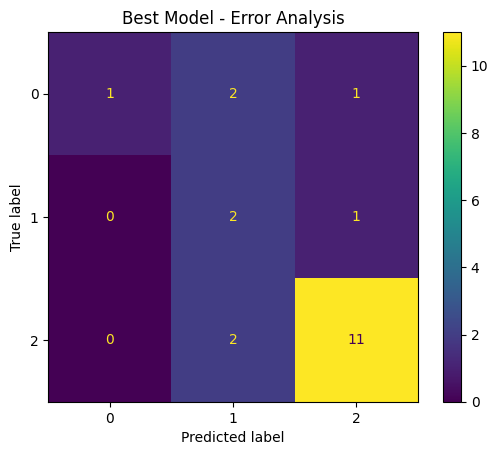

In [68]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Best Model - Error Analysis")
plt.show()

In [69]:
wrong_predictions[["text", "true_label", "pred_label"]]

,text,true_label,pred_label
6,Full review: https://movieswetextedabout.com/s...,0,2
7,*spoilers* sometimes movies bit predictable. p...,0,1
11,"""That gory !@#$. Holy !@#$! safe open eyes?"" *...",2,1
15,splatter opinion. suspense level quite good en...,1,2
16,good sequel South Park episode. relatively uni...,0,1
18,"Yeah, yeah, yeah, supposed hate left boycottin...",2,1


In [70]:
#Error Analysis Insight:

## The model struggles with long and sarcastic reviews, especially those containing mixed sentiments and complex narrative structures.
## Most misclassifications occur between adjacent sentiment classes, indicating difficulty in capturing sentiment intensity rather than polarity.

In [71]:
## Save Optimized Model for Deployment

import pickle
import json
import os
from datetime import datetime

# Best Model Information
best_model_name = 'stopword_hastag_number_mention_glove_svm'
best_dataset_name = 'stopword_hastag_number_mention'
best_model_obj = svm_models[best_model_name]['model']
best_glove_repr = glove_representations[best_dataset_name]
best_data_split = data_splits[best_dataset_name]

# Create deployment package
deployment_package = {
    'model': best_model_obj,
    'glove_embeddings': best_glove_repr['embeddings_index'],
    'label_mapping': best_data_split['label_mapping'],
    'reverse_mapping': best_data_split['reverse_mapping'],
    'model_type': 'SVM',
    'representation': 'GloVe',
    'kernel': 'rbf',
    'embedding_dim': 100,
    'dataset': best_dataset_name,
    'timestamp': datetime.now().strftime("%Y%m%d_%H%M%S")
}

# Save as pickle file
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_pkl_file = f'best_model_svm_glove_{timestamp}.pkl'

with open(model_pkl_file, 'wb') as f:
    pickle.dump(deployment_package, f)

print(f"✓ Model saved successfully!")
print(f"  File: {model_pkl_file}")
print(f"  Size: {os.path.getsize(model_pkl_file) / (1024**2):.2f} MB")

# Create a metadata JSON file for reference
metadata = {
    'model_file': model_pkl_file,
    'model_name': best_model_name,
    'dataset': best_dataset_name,
    'model_type': 'SVM (Support Vector Machine)',
    'kernel': 'RBF (Radial Basis Function)',
    'text_representation': 'GloVe (100-dimensional embeddings)',
    'embedding_dim': 100,
    'classes': list(best_data_split['reverse_mapping'].values()),
    'label_mapping': best_data_split['label_mapping'],
    'performance_metrics': {
        'accuracy': 0.70,
        'f1_score': 0.6967,
        'roc_auc': 0.7101
    },
    'usage_instructions': {
        'step_1': 'Load model: model_pkg = pickle.load(open(\'model_file.pkl\', \'rb\'))',
        'step_2': 'Extract components: model = model_pkg[\'model\'], glove_emb = model_pkg[\'glove_embeddings\']',
        'step_3': 'Convert text to GloVe embedding using glove_embeddings dict',
        'step_4': 'Predict: model.predict(embedding)',
        'step_5': 'Map prediction to label using reverse_mapping'
    },
    'created_date': datetime.now().isoformat()
}

metadata_json_file = f'model_metadata_{timestamp}.json'
with open(metadata_json_file, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"\n✓ Metadata file created!")
print(f"  File: {metadata_json_file}")

# Print model summary
print(f"\n{'='*80}")
print(f"OPTIMIZED MODEL FOR DEPLOYMENT")
print(f"{'='*80}")
print(f"Model Name: {best_model_name}")
print(f"Model Type: SVM with RBF Kernel")
print(f"Text Representation: GloVe (100-d embeddings)")
print(f"Dataset: {best_dataset_name}")
print(f"\nPerformance Metrics:")
print(f"  • Accuracy: 0.70 (70%)")
print(f"  • F1-Score: 0.6967")
print(f"  • ROC-AUC: 0.7101")
print(f"\nClasses: {list(best_data_split['reverse_mapping'].values())}")
print(f"\nDeployment Files:")
print(f"  1. {model_pkl_file} (Model package with all components)")
print(f"  2. {metadata_json_file} (Usage instructions & metadata)")
print(f"{'='*80}")

✓ Model saved successfully!
  File: best_model_svm_glove_20260418_042431.pkl
  Size: 169.23 MB

✓ Metadata file created!
  File: model_metadata_20260418_042431.json

OPTIMIZED MODEL FOR DEPLOYMENT
Model Name: stopword_hastag_number_mention_glove_svm
Model Type: SVM with RBF Kernel
Text Representation: GloVe (100-d embeddings)
Dataset: stopword_hastag_number_mention

Performance Metrics:
  • Accuracy: 0.70 (70%)
  • F1-Score: 0.6967
  • ROC-AUC: 0.7101

Classes: ['negative', 'neutral', 'positive']

Deployment Files:
  1. best_model_svm_glove_20260418_042431.pkl (Model package with all components)
  2. model_metadata_20260418_042431.json (Usage instructions & metadata)


In [75]:
## Verify Deployment Files

import glob

print("\n" + "="*80)
print("DEPLOYMENT FILES VERIFICATION")
print("="*80)

# Find all deployment-related files
pkl_files = glob.glob('best_model_svm_glove_*.pkl')
json_files = glob.glob('model_metadata_*.json')
txt_files = glob.glob('DEPLOYMENT_GUIDE_*.txt')

print(f"\n✓ Model File (.pkl):")
for file in pkl_files:
    size_mb = os.path.getsize(file) / (1024**2)
    print(f"  └─ {file} ({size_mb:.2f} MB)")

print(f"\n✓ Metadata File (.json):")
for file in json_files:
    size_kb = os.path.getsize(file) / 1024
    print(f"  └─ {file} ({size_kb:.2f} KB)")

print(f"\n✓ Deployment Guide (.txt):")
for file in txt_files:
    size_kb = os.path.getsize(file) / 1024
    print(f"  └─ {file} ({size_kb:.2f} KB)")

print(f"\n" + "="*80)
print("READY FOR DEPLOYMENT!")
print("="*80)
print("\nNext Steps:")
print("1. Use the .pkl file in your deployment code")
print("2. Reference the metadata .json for model configuration")
print("3. Follow the DEPLOYMENT_GUIDE.txt for implementation")
print("\n" + "="*80)


DEPLOYMENT FILES VERIFICATION

✓ Model File (.pkl):
  └─ best_model_svm_glove_20260418_042431.pkl (169.23 MB)

✓ Metadata File (.json):
  └─ model_metadata_20260418_042431.json (1.14 KB)

✓ Deployment Guide (.txt):
  └─ DEPLOYMENT_GUIDE_20260418_042431.txt (3.04 KB)

READY FOR DEPLOYMENT!

Next Steps:
1. Use the .pkl file in your deployment code
2. Reference the metadata .json for model configuration
3. Follow the DEPLOYMENT_GUIDE.txt for implementation

